<div style="text-align: center; font-family: 'Arial', sans-serif;">
    <h1 style="color: #2c3e50;">Security and Privacy in Machine Learning</h1>
    <h3 style="color: #34495e;">Course Code: 40816</h3>
    <h3 style="color: #7f8c8d;">Instructor: Dr. Amir Mahdi Sadeghzadeh</h3>
    <h3 style="color: #95a5a6;">Sharif University of Technology, Iran</h3>
    <h3 style="color: #bdc3c7;">CE Department, Fall 2024</h3>
    <h3 style="color: #d35400;">Computer Assignment 5</h3>
    <h4 style="color: #e67e22;">Topic: Differential Privacy</h4>
</div>


<div style="text-align: left; font-family: 'Arial', sans-serif; font-size: 14px;">
    <h2 style="color: #3498db;">Introduction</h2>
    <p>This notebook contains the implementation for Computer Assignment 5 on Differential Privacy. Follow the instructions carefully and ensure your code adheres to the provided guidelines.</p>
</div>


<div style="text-align: left; font-family: 'Arial', sans-serif; font-size: 14px;">
    <h2 style="color: #9b59b6;">Personal Data</h2>
    <p>Please enter your student number, first name, and last name in the following cell.</p>
</div>

In [1]:
# Enter your personal details below
student_number = "403206554"  # Replace with your student number
first_name = "Alireza"      # Replace with your first name
last_name = "Farajtabrizi"       # Replace with your last name

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h1 style="color: #2c3e50;">Part 0: Introduction to Differential Privacy</h1>
</div>

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #34495e;">Question 0: Differential Privacy Definitions (5 Points)</h2>
</div> 

Provide a brief summary of Differential Privacy principles. Define $\epsilon$-differential privacy and explain its significance in protecting individual data privacy.

#### My Answer: Differential Privacy is a method and definition that quantifies privacy loss and leakage in a computable, numeric way. Its main goal is to enable answering queries from data while limiting the information revealed about any individual.

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h1 style="color: #2c3e50;">Part 1: Mechanisms for Differential Privacy</h1>

In [2]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml # need sklearn >= 0.22
import scipy as sp
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVC
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelBinarizer

Below we provide a helper function to draw bar plots from pandas Series.

In [3]:
def bar_plot_pandas(series1, series2=None, label1="Series 1", label2="Series 2", title=""):
    '''
    Draws a bar plot of one Pandas Series, or two pandas Series with the same index
    
    Parameters
    ----------
    series1 : Series of float
        First input
    series2 : Series of float, optional
        Second input (with same index)
    label1 : string, optional
        Label for the first series
    label2 : string, optional
        Label for the second series
    title : string, optional
        Plot title
    '''
    if series2 is None:
        series1.plot.bar()
        plt.xlabel("Index")
        plt.ylabel("Values")
        plt.title(title if title else "Bar Plot")
        plt.legend([label1])
        plt.show()
    else:
        concat_series = pd.DataFrame({label1: series1, label2: series2}).reset_index()
        concat_series.plot.bar(x="index", y=[label1, label2], xlabel="", title=title)
        plt.xlabel("Index")
        plt.ylabel("Values")
        plt.title(title if title else "Comparison Bar Plot")
        plt.legend([label1, label2])
        plt.show()

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Dataset</h2>
</div>

We will be working with a dataset from the US Census (also known as the Adult dataset). You can read about the dataset [here](https://archive.ics.uci.edu/ml/datasets/census+income).

The following line loads the dataset from [OpenML](https://www.openml.org/) with the `fetch_openml` method of `sklearn`. The option `as_frame=True` (**requires sklearn version >= 0.22**) loads the dataset in `pandas DataFrame` format: this keeps the attributes in their original form and will be more convenient to work with. If you prefer working with a numpy array (not recommended), set `as_frame=False`.

In [4]:
# Fetching the Adult dataset from OpenML
dataset_handle = fetch_openml(name='adult', version=2, as_frame=True)
dataset = dataset_handle.frame

Take a look at the dataset, in particular the number of rows (individuals), the number of columns (attributes) and what they represent.

In [5]:
# Exploring the dataset
n, d = dataset.shape  # Number of rows and columns
print(f"Dataset contains {n} rows (individuals) and {d} columns (attributes).")
print("\nPreview of the dataset:")
dataset.head(4)

Dataset contains 48842 rows (individuals) and 15 columns (attributes).

Preview of the dataset:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K


<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 1 (non-private queries) (7 Points)</h2>
</div>

Implement a function for each of these types of queries (without privacy) and test them on the dataset:
- **Simple count queries**: it takes as input a dataset (`DataFrame`), a categorical attribute (e.g., `"sex"`) and a value (e.g., `"Male"`), and returns how many rows in the dataset have the prescribed attribute value.
- **Averaging queries**: it takes as input a dataset and a numeric attribute (e.g., `"age"`), and returns the average value of this attribute in the dataset.
- **Histogram queries**: it takes as input a dataset and a categorical attribute (e.g., `"sex"`), and returns the histogram of counts for this attribute in the dataset (i.e., for each possible value of the attribute, how many rows have this value).

Reminder: for a DataFrame `df`, we can access the column corresponding to an attribute `attr` by `df[attr]`. The method `value_counts()` allows to build a histogram of a column. To plot a pandas Series `s` as a histogram, you can use `s.plot.bar()`.

Note: You can use the function `bar_plot_pandas` provided in the preamble to draw a bar plot of a pandas Series, which is useful to show histograms.

In [6]:
def count_query(df, attribute, value):
    '''
    Parameters
    ----------
    df : DataFrame
        Dataset
    attribute : string
        Name of an attribute with categorical values
    value : string or int
        Value of attribute to count
        
    Returns
    -------
    count : int
        The number of records with `attribute=value` in dataset `df`
    '''
    
    # TO COMPLETE
    
    return len(df[df[attribute] == value])

In [7]:
count_query(dataset, "sex", "Male")

32650

In [8]:
def average_query(df, attribute):
    '''
    Parameters
    ----------
    df : DataFrame
        Dataset
    attribute : string
        Name of an attribute with numeric values
        
    Returns
    -------
    average : float
        The average value of `attribute` in dataset `df`
    '''
        
    # TO COMPLETE
    return df[attribute].mean()

In [9]:
average_query(dataset, "age")

38.64358543876172

In [10]:
def histogram_query(df, attribute):
    '''
    Parameters
    ----------
    df : DataFrame
        Dataset
    attribute : string
        Name of an attribute with categorical values
        
    Returns
    -------
    histogram : array or Series of int
        The histogram of `attribute`, i.e., the number of times each value of `attribute` appears in `df`
    '''
    # TO COMPLETE
    return df[attribute].value_counts()

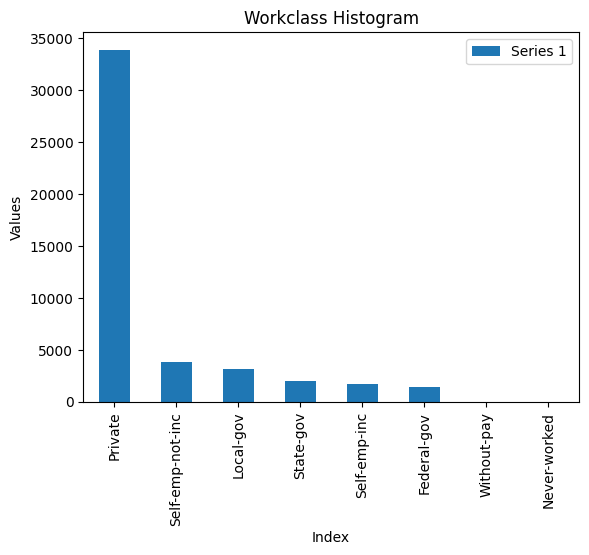

In [11]:
bar_plot_pandas(histogram_query(dataset, "workclass"), title="Workclass Histogram")

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 2 (Laplace mechanism) (10 Points)</h2>
</div>

Implement the Laplace mechanism, i.e., a function which takes as input a (non-private) query output, the query's $\ell_1$ sensitivity, the desired value of $\epsilon$ and a random seed (for reproducibility), and returns a $\epsilon$-differentially private estimate of the query. To draw Laplace noise, check `np.random.laplace`. The function should work with queries that output a scalar (like simple count and averaging queries), as well as those that output a vector (like histogram queries).

In [12]:
def laplace_mechanism(q, s1, eps, random_state=None):
    '''
    Parameters
    ----------
    q : float or array/Series of float
        The non-private output of the query
    s1 : float
        The L1 sensitivity of the query
    eps : float
        Parameter epsilon of differential privacy
    random_state : int, optional (default=None)
        Random seed
        
    Returns
    -------
    private_q : float or array/Series of float
        An eps-DP evaluation of the query
    '''

    rng = np.random.RandomState(random_state)
    
    # TO COMPLETE
    if hasattr(q, 'shape'): # query output is multi-dimensional
        return q + rng .laplace(loc=0, scale=s1/eps, size = q.shape)
    else: # query output is a scalar
        return q + rng .laplace(loc=0, scale=s1/eps)

In [13]:
non_private_query = average_query(dataset, "age")
private_query = laplace_mechanism(non_private_query, s1=1, eps=1, random_state=42)
print(f"The result of non-private query vs private query (Laplace Mechanism) for age average query {non_private_query:.4f} vs {private_query:.4f}")

The result of non-private query vs private query (Laplace Mechanism) for age average query 38.6436 vs 38.3547


In [14]:
non_private_query = histogram_query(dataset, "workclass")
print(non_private_query)
#bar_plot_pandas(non_private_query, title="Non-Private Query")

private_query = laplace_mechanism(non_private_query, s1=1, eps=1, random_state=42)
print(private_query)
#bar_plot_pandas(private_query, title="Private Query")


Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: workclass, dtype: int64
Private             33905.711091
Self-emp-not-inc     3864.316974
Local-gov            3136.623599
State-gov            1981.219795
Self-emp-inc         1693.835367
Federal-gov          1430.835213
Without-pay            18.847275
Never-worked           11.318084
Name: workclass, dtype: float64


<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 3 (Laplace mechanism on count queries) (8 Points)</h2>
</div>

We would like to use the Laplace mechanism to:
- privately count the number of males in the dataset
- generate a private histogram of the `"workclass"` attribute

What is the sensitivity of the query in each case?

My Answer: For both case sensevity is 1.


Run the Laplace mechanism with different values of $\epsilon$ and compute the $\ell_1$-error with respect to the true (non-private) output to see the effect on the utility and compare with the formal error bound seen in the lecture. Recall that the mechanism is random, so unless you fix the seed you will get a different result at each execution. Visually compare the private and non-private histograms using the function `bar_plot_pandas` provided at the beginning of the notebook.

Note: you may round the outputs of the private mechanism to make them integers if you like. This can be considered as post-processing and thus preserves DP (see Bonus Question 5 to go further on this aspect).

My Answer: we have 2 bound:
#### 1- E[N]= S/e which is k/e 
#### Number of males: 1/e
#### Histogram of the workclass: 8/e

#### 2- Upper bound for 1-delta cases:
 ![My Image](upper_bound.PNG)
#### Number of males: delta = 1e-5 and k = 8 upperbound equals 13.6/e
#### Histogram of the workclass: delta = 1e-5 and k = 1 upperbound equals 11.5/e

In [45]:
def l1_error(a, b):
    '''
    Parameters
    ----------
    a : float or array/Series of float
        First input
    b : float or array/Series of float
        Second input
        
    Returns
    -------
    l1_error : float
        The L1 distance between `a` and `b`: ||a-b||_1
    '''

    # TO COMPLETE
    a = np.array(a)
    b = np.array(b)
    
    # Compute the L1 distance
    return np.sum(np.abs(a - b))

# list of (query,sensitivity) tuples to loop over
queries = [(count_query(dataset, "sex", "Male"), 1), (histogram_query(dataset, "workclass"), 1)]

for eps in [0.1, 1., 10]:
    print(f"Results for epsilon {eps}")
    for q, s in queries:
        private_query = laplace_mechanism(q, s, eps, 42)
        # creating float version
        if hasattr(private_query, 'astype'): 
            q = q.astype(float)
        
        # query output is a scalar
        else: 
            q = float(q)
            
        print(f"{l1_error(q,private_query):.4}")


Results for epsilon 0.1
2.889
92.5
Results for epsilon 1.0
0.2889
9.25
Results for epsilon 10
0.02889
0.925


In [49]:
laplace_mechanism(histogram_query(dataset, "workclass"), s, 1, 42)

Private             33905.711091
Self-emp-not-inc     3864.316974
Local-gov            3136.623599
State-gov            1981.219795
Self-emp-inc         1693.835367
Federal-gov          1430.835213
Without-pay            18.847275
Never-worked           11.318084
Name: workclass, dtype: float64

In [48]:
histogram_query(dataset, "workclass")

Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: workclass, dtype: int64

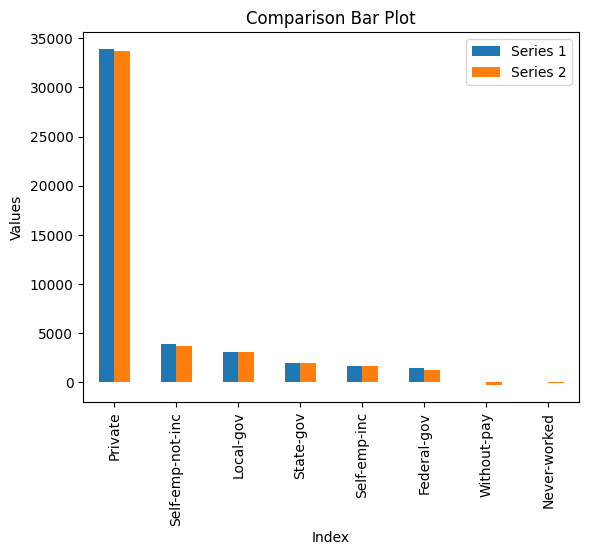

In [16]:
bar_plot_pandas(queries[1][0], laplace_mechanism(queries[1][0], 1, 0.01))

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 4 (Gaussian mechanism and comparison with Laplace) (12 Points)</h2>
</div>

Implement the Gaussian mechanism (to draw Gaussian noise, check `np.random.normal`). Make an experimental comparison with the Laplace mechanism by plotting the privacy-utility trade-off for a 1D query of your choice. For the Gaussian mechanism, study the influence of $\delta$.

In [17]:
def gaussian_mechanism(q, s2, eps, delta, random_state=None):
    '''
    Parameters
    ----------
    q : float or array/Series of float
        The non-private output of the query
    s2 : float
        The L2 sensitivity of the query
    eps : float
        Parameter epsilon of differential privacy
    delta : float
        Parameter delta of differential privacy
    random_state : int, optional (default=None)
        Random seed
        
    Returns
    -------
    private_q : float or array/Series of float
        An (eps,delta)-DP evaluation of the query
    '''
    
    rng = np.random.RandomState(random_state)
    std = (s2 * np.sqrt(2 * np.log(1.25 / delta))) / eps
    
    # TO COMPLETE
    if hasattr(q, 'shape'): # query output is multi-dimensional
        return q + rng.normal(loc=0, scale=std, size=q.shape)
    else: # query output is a scalar
        return q + rng.normal(loc=0, scale=std)

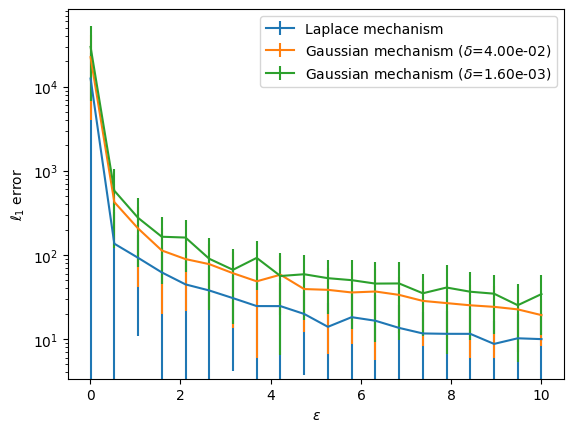

In [55]:
q = average_query(dataset, "hours-per-week") 
s = dataset["hours-per-week"].max()-dataset["hours-per-week"].min()
eps_list = np.linspace(0.01, 10.0, num=20)
delta1 = 1. / n**2
delta2 = 1. / n**4
n_runs = 50

error = np.zeros((len(eps_list), 3, n_runs))

for i, eps in enumerate(eps_list):
    for r in range(n_runs):
        error[i, 0, r] = l1_error(laplace_mechanism(q=q, s1=s, eps=eps), q)
        error[i, 1, r] = l1_error(gaussian_mechanism(q=q, s2=s, eps=eps, delta=delta1), q)
        error[i, 2, r] = l1_error(gaussian_mechanism(q=q, s2=s, eps=eps, delta=delta2), q)
        pass
    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(eps_list, error[:, 0, :].mean(axis=1), error[:, 0, :].std(axis=1), label='Laplace mechanism')
ax.errorbar(eps_list, error[:, 1, :].mean(axis=1), error[:, 1, :].std(axis=1),
            label='Gaussian mechanism ($\delta$=' + "{:.2e}".format(delta1) + ')')
ax.errorbar(eps_list, error[:, 2, :].mean(axis=1), error[:, 2, :].std(axis=1),
            label='Gaussian mechanism ($\delta$=' + "{:.2e}".format(delta2) + ')')
plt.xlabel("$\epsilon$")
plt.ylabel("$\ell_1$ error")
ax.set_yscale('log')
ax.legend()
plt.show()

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h1 style="color: #2c3e50;">Part 3: Applications of Differential Privacy</h1>
</div>

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 5 (contingency tables and the "paradox" of parallel composition) (8 Points)</h2>
</div>

We can go beyond histograms and build contingency tables across two (or even more) variables. Implement a function for such queries using `crosstab` from pandas, and use the Laplace mechanism to privately find out how people in the dataset break down according to the combination of `'gender'` and `'marital-status'`. You may need to adapt your implementation of Laplace to work with k-way tables (e.g., by using the method `applymap` together with a function that adds 1D Laplace noise).

Pushing this reasoning further, it may seem that there is a paradox because parallel composition gets us more information "for free" (e.g., we can build a k-way table over a large number of attributes that could ultimately reveal very precise information about individuals in the dataset, without increasing the privacy loss). This contradicts the principle that asking more things should cost something. Explain why there is in fact no paradox and what is the cost that one pays in this case (if needed, you can see what happens when privately releasing contingency tables across many columns).

My Answer: The privacy loss is defined about an indivisual data leakage. In K-way tables each indivisual is included only in 1 of the cells, therfore other cells have no information about that indivisual. As a result other cells won't sum up the infromation leak and privacy loss. 

In [19]:
def table_query(df, row_attr_list, col_attr_list):
    '''
    Parameters
    ----------
    df : DataFrame
        Dataset
    row_attr_list : list
        List of attributes
    col_attr_list : list
        List of attributes
        
    Returns
    -------
    cross_table : DataFrame
        Cross tabulation (contingency table) of `df` according to `row_attr_list` and `col_attr_list`
    '''

    # TO COMPLETE
    cross_table = pd.crosstab(
        index=[df[attr] for attr in row_attr_list], 
        columns=[df[attr] for attr in col_attr_list]
    )
    
    return cross_table

In [20]:
table_query(dataset, ["sex", "marital-status"], ["workclass"])

workclass                     Federal-gov  Local-gov  Never-worked  Private  \
sex    marital-status                                                         
Female Divorced                       143        389             0     2870   
       Married-AF-spouse                2          0             0       16   
       Married-civ-spouse              60        232             1     1595   
       Married-spouse-absent            7         22             0      219   
       Never-married                  176        432             2     5460   
       Separated                       26         63             0      697   
       Widowed                         38        120             0      742   
Male   Divorced                        95        140             1     1832   
       Married-AF-spouse                1          0             0        8   
       Married-civ-spouse             661       1304             0    12878   
       Married-spouse-absent            8         11             1      234   
       Never-married                  192        366             5     6783   
       Separated                       13         37             0      422   
       Widowed                         10         20             0      150   

workclass                     Self-emp-inc  Self-emp-not-inc  State-gov  \
sex    marital-status                                                     
Female Divorced                         48               157        214   
       Married-AF-spouse                 0                 1          2   
       Married-civ-spouse               72               195        110   
       Married-spouse-absent             2                16         13   
       Never-married                    53               152        338   
       Separated                         8                30         43   
       Widowed                          28                78         43   
Male   Divorced                         98               275        102   
       Married-AF-spouse                 0                 2          0   
       Married-civ-spouse             1192              2359        780   
       Married-spouse-absent             6                32         12   
       Never-married                   158               461        298   
       Separated                        17                55         22   
       Widowed                          13                49          4   

workclass                     Without-pay  
sex    marital-status                      
Female Divorced                         0  
       Married-AF-spouse                0  
       Married-civ-spouse               4  
       Married-spouse-absent            1  
       Never-married                    1  
       Separated                        0  
       Widowed                          1  
Male   Divorced                         0  
       Married-AF-spouse                0  
       Married-civ-spouse               9  
       Married-spouse-absent            0  
       Never-married                    5  
       Separated                        0  
       Widowed                          0

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 6 (Laplace mechanism on average queries) (9 Points)</h2>
</div>

We would like to use the Laplace mechanism to privately estimate the average age of people in the dataset. We assume that the number of people in the dataset is public.

1. Propose and implement simple practical strategies to compute or estimate the sensitivity of this query in the following two scenarios, and discuss the merits and/or drawbacks of your proposals:
  - You are the trusted curator: you have access to the raw dataset and would like to release an estimate of the average age of people in the dataset with differential privacy guarantees.
  - You are an external data analyst: you do not have access to the raw dataset but only to an API to send queries. You have to convince the trusted curator that the proposed sensitivity is safe.
2. Suggest some ideas regarding how we could change a bit the query to get a simple and safe bound on sensitivity, at the expense of possibly introducing some bias in the output. Implement the proposed solution. Hint: the method `clip` from pandas might be useful here.

##### My Answer:
##### 1-a: What matters here is sensitivity, and we need to calculate or estimate it somehow. In the first scenario, we simply need to find the maximum and minimum age and use the formula (max-min)/(number of people) as the sensitivity.
##### 1-b: In this case, we don't have access to the maximum and minimum value, so we can use a sufficiently large number, such as 100 or 200, and calculate sensitivity based on that.

##### 2: We have 2 options here, we can clip the ages to a maximum range like 100 either in the database or while computing the query.

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 7 (average over a subset) (6 Points)</h2>
</div>

We would now like to compute the average age of divorced people. How can we use the Laplace mechanism to privately answer this query? Implement your solution.

##### all we need to do is to give a cliped version of data to laplace mechanism.

In [21]:
cliped_df = copy.deepcopy(dataset)
cliped_df["age"] = cliped_df["age"].clip(0,100)
non_private_query = average_query(cliped_df[cliped_df["marital-status"]=="Divorced"], "age")
laplace_mechanism(non_private_query, s1=100/len(cliped_df), eps=1, random_state=42)

43.15861246219529

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 8 (non-private SGD) (17 Points)</h2>
</div>

In this question, we will implement our own simple version of SGD, as well as define our own sklearn-compatible $\ell_2$-regularized logistic regression estimator. This will be convenient when we will implement a differentially private version in Question 9.

Below, you are given several pieces of code:
1. A function `sgd` which implements SGD: it is meant to be generic in the sense that it takes as input a function `obj_and_grad` which computes the value and the gradient of the desired objective function. **This function has missing parts that you need to complete**.


2. A function `my_logistic_obj_and_grad` (adapted from [the version from sklearn](https://github.com/scikit-learn/scikit-learn/blob/0fb307bf39bbdacd6ed713c00724f8f871d60370/sklearn/linear_model/_logistic.py#L84)) which computes the value and gradient of the logistic regression problem. You do not need to modify this function.


3. A class `MySGDLogisticRegression` which defines a sklearn estimator for logistic regression, where the model is fit using SGD using the previous two functions. You do not need to modify this function.

Spend a bit of time to get familiar with the code provided, then complete the missing bits in the `sgd` function. Make sure it works by trying it on the binary classification dataset that you previously loaded.

In [22]:
def sgd(X, y, gamma, n_iter, obj_and_grad, theta_init, n_batch=1, freq_obj_eval=10,
        n_obj_eval=1000, random_state=None):
    """Stochastic Gradient Descent (SGD) algorithm

    Parameters
    ----------
    X : array, shape (n, d)
        The data
    y : array, shape (n,)
        Binary labels (-1, 1).
    gamma : float | callable
        The step size. Can be a constant float or a function
        that allows to have a variable step size
    n_iter : int
        The number of iterations
    obj_and_grad : callable
        A function which takes as a vector of shape (p,), a dataset of shape (n_batch, d)
        and a label vector of shape (n_batch,), and returns the objective value and gradient.
    theta_init : array, shape (p,)
        The initial value for the model parameters
    n_batch : int
        Size of the mini-batch to use at each iteration of SGD.
    freq_obj_eval : int
        Specifies the frequency (in number of iterations) at which we compute the objective
    n_obj_eval : int
        The number of points on which we evaluate the objective
    random_state : int
        Random seed to make the algorithm deterministic


    Returns
    -------
    theta : array, shape=(p,)
        The final value of the model parameters
    obj_list : list of length (n_iter / freq_obj_eval)
        A list containing the value of the objective function computed every freq_obj_eval iterations
    """
    
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    p = theta_init.shape[0]
    
    theta = theta_init.copy()

    # if a constant step size was provided, we turn it into a constant function
    if not callable(gamma):
        def gamma_func(t):
            return gamma
    else:
        gamma_func = gamma
    
    # list to record the evolution of the objective (for plotting)
    obj_list = []
    # we draw a fixed subset of points to monitor the objective
    idx_eval = rng.randint(0, n, n_obj_eval)

    for t in range(n_iter):
        if t % freq_obj_eval == 0:
            # evaluate objective
            obj, _ = obj_and_grad(theta, X[idx_eval, :], y[idx_eval])
            obj_list.append(obj)
        
        # TO COMPLETE
        idx_batch = rng.choice(n, n_batch, replace=False)
        X_batch = X[idx_batch]
        y_batch = y[idx_batch]
        
        _, grad = obj_and_grad(theta, X_batch, y_batch)
        theta -= gamma_func(t) * grad
        
    return theta, obj_list

In [23]:
from sklearn.linear_model._base import LinearClassifierMixin, SparseCoefMixin, BaseEstimator
from sklearn.utils.extmath import log_logistic, safe_sparse_dot
#from sklearn.linear_model._logistic import _intercept_dot
from scipy.special import expit
from sklearn.utils.validation import check_X_y
def intercept_dot(w, X, y):

    """Computes y * np.dot(X, w).
    It takes into consideration if the intercept should be fit or not.
    Parameters
    ----------
    w : ndarray, shape (n_features,) or (n_features + 1,)
        Coefficient vector.
    X : {array-like, sparse matrix}, shape (n_samples, n_features)
        Training data.
    y : ndarray, shape (n_samples,)
        Array of labels.
    """
    c = 0.
    if w.size == X.shape[1] + 1:
        c = w[-1]
        w = w[:-1]

    z = safe_sparse_dot(X, w) + c

    y = np.asarray(y)
    z = np.asarray(z)
    return w, c, y * z

In [24]:
def my_logistic_obj_and_grad(theta, X, y, lamb):
    """Computes the value and gradient of the objective function of logistic regression defined as:
    min (1/n) \sum_i log_loss(theta;X[i,:],y[i]) + (lamb / 2) \|w\|^2,
    where theta = w (if no intercept), or theta = [w b] (if intercept)

    Parameters
    ----------
    theta_init : array, shape (d,) or (d+1,)
        The initial value for the model parameters. When an intercept is used, it corresponds to the last entry
    X : array, shape (n, d)
        The data
    y : array, shape (n,)
        Binary labels (-1, 1)
    lamb : float
        The L2 regularization parameter


    Returns
    -------
    obj : float
        The value of the objective function
    grad : array, shape (d,) or (d+1,)
        The gradient of the objective function
    """
    n_samples, n_features = X.shape
    grad = np.empty_like(theta)
    
    w, c, yz = intercept_dot(theta, X, y)

    # Logistic loss is the negative of the log of the logistic function
    obj = -np.mean(-np.logaddexp(0, -yz)) + .5 * lamb * np.dot(w, w)

    z = expit(yz)
    z0 = (z - 1) * y

    grad[:n_features] = safe_sparse_dot(X.T, z0) / n_samples + lamb * w

    # Case where we fit the intercept
    if grad.shape[0] > n_features:
        grad[-1] = z0.sum() / n_samples

    return obj, grad


class MySGDLogisticRegression(BaseEstimator, LinearClassifierMixin, SparseCoefMixin):
    """Our own sklearn estimator for logistic regression defined as:
    min (1/n) \sum_i log_loss(theta;X[i,:],y[i]) + (lamb / 2) \|w\|^2,
    where theta = [w b]
    
    Parameters
    ----------
    gamma : float | callable
        The step size. Can be a constant float or a function
        that allows to have a variable step size
    n_iter : int
        The number of iterations
    lamb : float
        The L2 regularization parameter
    n_batch : int
        Size of the mini-batch to use at each iteration of SGD.
    freq_obj_eval : int
        Specifies the frequency (in number of iterations) at which we compute the objective
    n_obj_eval : int
        The number of points on which we evaluate the objectuve
    random_state : int
        Random seed to make the algorithm deterministic
        
    Attributes
    ----------
    coef_ : (p,)
        The weights of the logistic regression model.
    intercept_ : (1,)
        The intercept term of the logistic regression model.
    obj_list_: list of length (n_iter / freq_obj_eval)
        A list containing the value of the objective function computed every freq_loss_eval iterations
    """
    
    def __init__(self, gamma, n_iter, lamb=0, n_batch=1, freq_obj_eval=10, n_obj_eval=1000, random_state=None):
        self.gamma = gamma
        self.n_iter = n_iter
        self.lamb = lamb
        self.n_batch = n_batch
        self.freq_obj_eval = freq_obj_eval
        self.n_obj_eval = n_obj_eval
        self.random_state = random_state
    
    def fit(self, X, y):
        
        # WARNING: assumes labels are -1, 1
        X, y = check_X_y(X, y, accept_sparse='csr', dtype=[np.float64, np.float32], order="C")
        self.classes_ = np.unique(y)    
                
        p = X.shape[1]
        theta_init = np.zeros(p+1) # initialize parameters to zero
        # define the function for value and gradient needed by SGD
        obj_grad = lambda theta, X, y: my_logistic_obj_and_grad(theta, X, y, lamb=self.lamb)
        theta, obj_list = sgd(X, y, self.gamma, self.n_iter, obj_grad, theta_init, self.n_batch,
                              self.freq_obj_eval, self.n_obj_eval, self.random_state)
        
        # save the learned model into the appropriate quantities used by sklearn
        self.intercept_ = np.expand_dims(theta[-1], axis=0)
        self.coef_ = np.expand_dims(theta[:-1], axis=0)
        
        # also save list of objective values during optimization for plotting
        self.obj_list_ = obj_list
        
        return self

In [25]:
from sklearn.datasets import load_breast_cancer
scaler = StandardScaler()
data = load_breast_cancer()

X = data.data
y = data.target
y = y * 2 - 1

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Test accuracy 0.9824561403508771


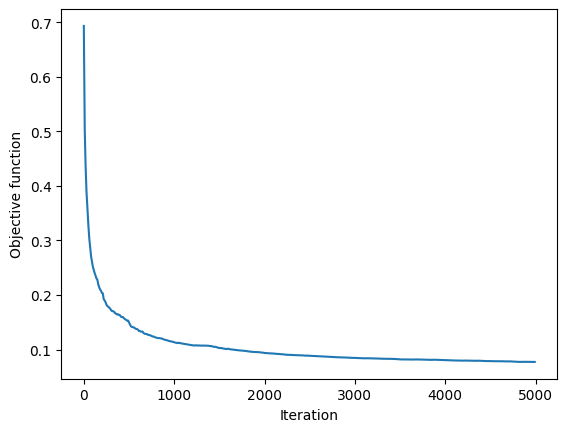

In [26]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)

mlr = MySGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, random_state=42)
mlr.fit(X_train, y_train)
print("Test accuracy", mlr.score(X_test, y_test))

obj_list = mlr.obj_list_
iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
plt.plot(iter_list, obj_list)
plt.xlabel("Iteration")
plt.ylabel("Objective function")
plt.show()

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Question 9 (private SGD) (18 Points)</h2>
</div>

We will now implement and experiment with DP-SGD:
1. Following the model of the function `sgd`, implement a new function `private_sgd` which implements DP-SGD **with mini-batch size of 1 and no regularization**. It can take as input the desired value of $\epsilon$ and $\delta$ for the $(\epsilon,\delta)$-DP, or alternatively the standard deviation of the Gaussian noise to add at each iteration. Note: you do not need to make the objective plotting part private (this is only for monitoring).


2. Following the model of the class `MySGDLogisticRegression`, implement a new class `MyPrivateSGDLogisticRegression` which implements differentially private logistic regression trained using your DP-SGD implementation above.


3. Experiment with different values of $\epsilon$ and $\delta$, number of iterations and step size, and study the effect on the convergence of SGD as well as the test accuracy of the resulting model. Describe your observations. How should the number of iterations depend on the level of privacy? How can we choose the number of iterations and step size in practice?

In [27]:
def private_sgd(X, y, gamma, n_iter, obj_and_grad, theta_init, n_batch=1, freq_obj_eval=10, n_obj_eval=1000,
                epsilon=1, delta=1e-5, c=10, random_state=None):
    """Stochastic Gradient Descent (SGD) algorithm

    Parameters
    ----------
    X : array, shape (n, d)
        The data
    y : array, shape (n,)
        Binary labels (-1, 1).
    gamma : float | callable
        The step size. Can be a constant float or a function
        that allows to have a variable step size
    n_iter : int
        The number of iterations
    obj_and_grad : callable
        A function which takes as a vector of shape (p,), a dataset of shape (n_batch, d)
        and a label vector of shape (n_batch,), and returns the objective value and gradient.
    theta_init : array, shape (p,)
        The initial value for the model parameters
    n_batch : int
        Size of the mini-batch to use at each iteration of SGD.
    freq_obj_eval : int
        Specifies the frequency (in number of iterations) at which we compute the objective
    n_obj_eval : int
        The number of points on which we evaluate the objective
    random_state : int
        Random seed to make the algorithm deterministic


    Returns
    -------
    theta : array, shape=(p,)
        The final value of the model parameters
    obj_list : list of length (n_iter / freq_obj_eval)
        A list containing the value of the objective function computed every freq_obj_eval iterations
    """
    
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    p = theta_init.shape[0]
    
    q = n_batch/n
    std = c * q * np.sqrt(n_iter*np.log(1/delta)) / epsilon
    
    theta = theta_init.copy()

    # if a constant step size was provided, we turn it into a constant function
    if not callable(gamma):
        def gamma_func(t):
            return gamma
    else:
        gamma_func = gamma
    
    # list to record the evolution of the objective (for plotting)
    obj_list = []
    # we draw a fixed subset of points to monitor the objective
    idx_eval = rng.randint(0, n, n_obj_eval)

    for t in range(n_iter):
        if t % freq_obj_eval == 0:
            # evaluate objective
            obj, _ = obj_and_grad(theta, X[idx_eval, :], y[idx_eval])
            obj_list.append(obj)
        
        # TO COMPLETE
        idx_batch = rng.choice(n, n_batch, replace=False)
        X_batch = X[idx_batch]
        y_batch = y[idx_batch]
        
        _, grad = obj_and_grad(theta, X_batch, y_batch)
        
        grad = grad/(max(1,np.linalg.norm(grad)/c))

        grad += rng.normal(loc=0, scale=std, size=grad.shape)
        
        theta -= gamma_func(t) * grad
        
    return theta, obj_list

In [28]:
class MyPrivateSGDLogisticRegression(BaseEstimator, LinearClassifierMixin, SparseCoefMixin):
    """Our own sklearn estimator for logistic regression defined as:
    min (1/n) \sum_i log_loss(theta;X[i,:],y[i]) + (lamb / 2) \|w\|^2,
    where theta = [w b]
    
    Parameters
    ----------
    gamma : float | callable
        The step size. Can be a constant float or a function
        that allows to have a variable step size
    n_iter : int
        The number of iterations
    lamb : float
        The L2 regularization parameter
    n_batch : int
        Size of the mini-batch to use at each iteration of SGD.
    freq_obj_eval : int
        Specifies the frequency (in number of iterations) at which we compute the objective
    n_obj_eval : int
        The number of points on which we evaluate the objectuve
    random_state : int
        Random seed to make the algorithm deterministic
        
    Attributes
    ----------
    coef_ : (p,)
        The weights of the logistic regression model.
    intercept_ : (1,)
        The intercept term of the logistic regression model.
    obj_list_: list of length (n_iter / freq_obj_eval)
        A list containing the value of the objective function computed every freq_loss_eval iterations
    """
    
    def __init__(self, gamma, n_iter, lamb=0, n_batch=1, freq_obj_eval=10, n_obj_eval=1000, 
                 epsilon=1, delta=1e-5, c=10,random_state=None):
        self.gamma = gamma
        self.n_iter = n_iter
        self.lamb = lamb
        self.n_batch = n_batch
        self.freq_obj_eval = freq_obj_eval
        self.n_obj_eval = n_obj_eval
        self.epsilon = epsilon
        self.delta = delta
        self.c = c
        self.random_state = random_state
    
    def fit(self, X, y):
        
        # WARNING: assumes labels are -1, 1
        X, y = check_X_y(X, y, accept_sparse='csr', dtype=[np.float64, np.float32], order="C")
        self.classes_ = np.unique(y)    
                
        p = X.shape[1]
        theta_init = np.zeros(p+1) # initialize parameters to zero
        # define the function for value and gradient needed by SGD
        obj_grad = lambda theta, X, y: my_logistic_obj_and_grad(theta, X, y, lamb=self.lamb)
        theta, obj_list = private_sgd(X, y, self.gamma, self.n_iter, obj_grad, theta_init, self.n_batch,
                              self.freq_obj_eval, self.n_obj_eval, self.epsilon, self.delta, self.c, self.random_state)
        
        # save the learned model into the appropriate quantities used by sklearn
        self.intercept_ = np.expand_dims(theta[-1], axis=0)
        self.coef_ = np.expand_dims(theta[:-1], axis=0)
        
        # also save list of objective values during optimization for plotting
        self.obj_list_ = obj_list
        
        return self

Test accuracy 0.9824561403508771


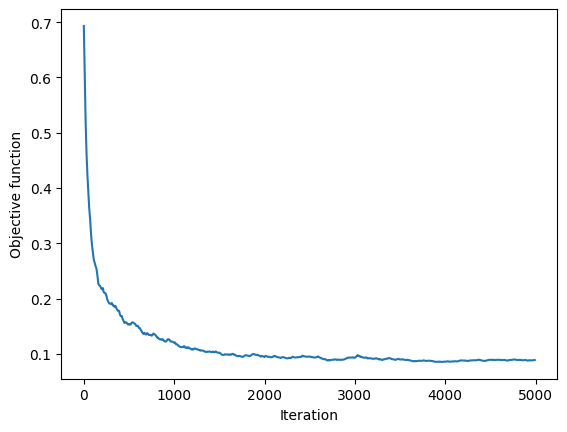

In [29]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)

mlr = MyPrivateSGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, epsilon=1, delta=1e-5, c=1, random_state=42)
mlr.fit(X_train, y_train)
print("Test accuracy", mlr.score(X_test, y_test))

obj_list = mlr.obj_list_
iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
plt.plot(iter_list, obj_list)
plt.xlabel("Iteration")
plt.ylabel("Objective function")
plt.show()

### epsilon and delta effect

_________________________________________________
Parameters: epsilon=0.1
Test accuracy: 0.7631578947368421
_________________________________________________
Parameters: epsilon=1
Test accuracy: 0.9824561403508771
_________________________________________________
Parameters: epsilon=10
Test accuracy: 0.9736842105263158


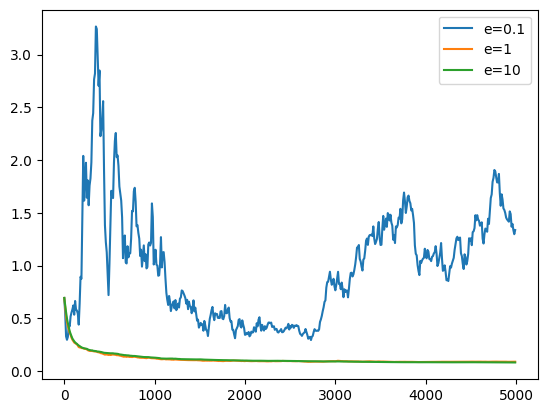

_________________________________________________
Parameters: delta=0.1
Test accuracy: 0.9736842105263158
_________________________________________________
Parameters: delta=1e-05
Test accuracy: 0.9824561403508771
_________________________________________________
Parameters: delta=1e-10
Test accuracy: 0.9736842105263158


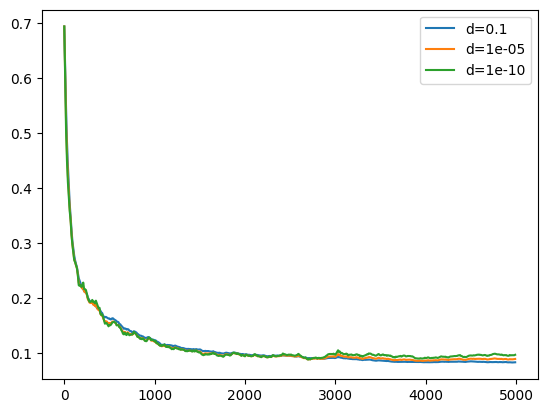

In [30]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)
for e in [0.1 ,1, 10]:
    mlr = MyPrivateSGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, epsilon=e, delta=1e-5, c=1, random_state=42)
    mlr.fit(X_train, y_train)
    print("_________________________________________________")
    print(f"Parameters: epsilon={e}")
    print("Test accuracy:", mlr.score(X_test, y_test))
    
    # Get objective function values and iterations
    obj_list = mlr.obj_list_
    iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
    
    # Plot on the same figure
    label = f"e={e}"
    plt.plot(iter_list, obj_list, label=label)
# Add legend and show the plot
plt.legend(loc="best")
plt.show()

for d in [1e-1, 1e-5, 1e-10]:
    mlr = MyPrivateSGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, epsilon=1, delta=d, c=1, random_state=42)
    mlr.fit(X_train, y_train)
    print("_________________________________________________")
    print(f"Parameters: delta={d}")
    print("Test accuracy:", mlr.score(X_test, y_test))
    
    # Get objective function values and iterations
    obj_list = mlr.obj_list_
    iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
    
    # Plot on the same figure
    label = f"d={d}"
    plt.plot(iter_list, obj_list, label=label)

# Add legend and show the plot
plt.legend(loc="best")
plt.show()

##### As you can see in figures above delta doesn't have high impact on the result if it is sufficently small, but on the other hand small epsilons can cost loss in accuracy gaining privacy.

### c effect

_________________________________________________
Parameters:c=0.1
Test accuracy: 0.9649122807017544
_________________________________________________
Parameters:c=1
Test accuracy: 0.9824561403508771
_________________________________________________
Parameters:c=10
Test accuracy: 0.8859649122807017


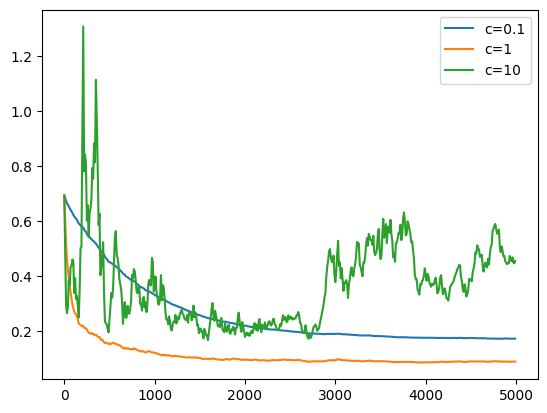

In [31]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)

for c in [0.1 ,1, 10]:
        mlr = MyPrivateSGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, epsilon=1, delta=1e-5, c=c, random_state=42)
        mlr.fit(X_train, y_train)
        print("_________________________________________________")
        print(f"Parameters:c={c}")
        print("Test accuracy:", mlr.score(X_test, y_test))
        
        # Get objective function values and iterations
        obj_list = mlr.obj_list_
        iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
        
        # Plot on the same figure
        label = f"c={c}"
        plt.plot(iter_list, obj_list, label=label)

# Add legend and show the plot
plt.legend(loc="best")
plt.show()

##### The effect of C was predictable as discussed in class neither to big nor too small Cs are suitable, cause big Cs result in large std for noise and small Cs ruin the gradiant.

### iterations and gamma effect

_________________________________________________
Parameters: iterations=1000
Test accuracy: 0.9649122807017544
_________________________________________________
Parameters: iterations=5000
Test accuracy: 0.9824561403508771
_________________________________________________
Parameters: iterations=10000
Test accuracy: 0.9912280701754386


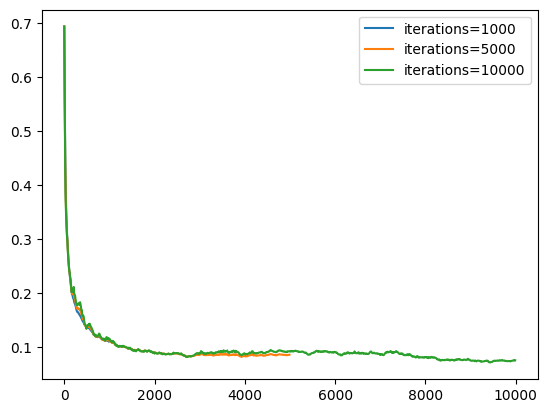

_________________________________________________
Parameters:lr=0.1
Test accuracy: 0.9649122807017544
_________________________________________________
Parameters:lr=0.01
Test accuracy: 0.9824561403508771
_________________________________________________
Parameters:lr=0.001
Test accuracy: 0.9736842105263158


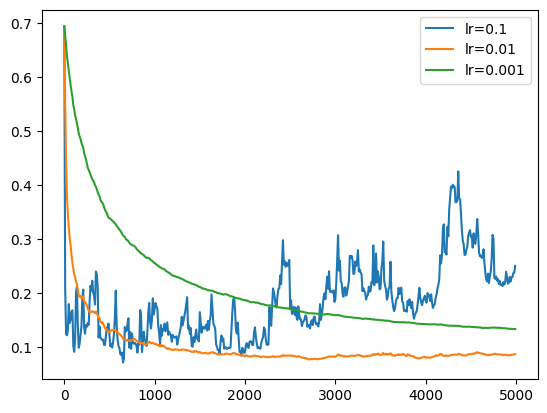

In [32]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)
for i in [1000 ,5000, 10000]:
    mlr = MyPrivateSGDLogisticRegression(gamma=gamma, n_iter=i, lamb=lamb, n_batch=n_batch, epsilon=e, delta=1e-5, c=c, random_state=42)
    mlr.fit(X_train, y_train)
    print("_________________________________________________")
    print(f"Parameters: iterations={i}")
    print("Test accuracy:", mlr.score(X_test, y_test))
    
    # Get objective function values and iterations
    obj_list = mlr.obj_list_
    iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
    
    # Plot on the same figure
    label = f"iterations={i}"
    plt.plot(iter_list, obj_list, label=label)

# Add legend and show the plot
plt.legend(loc="best")
plt.show()


for g in [0.1 ,0.01, 0.001]:
    mlr = MyPrivateSGDLogisticRegression(gamma=g, n_iter=n_iter, lamb=lamb, n_batch=n_batch, epsilon=e, delta=1e-5, c=c, random_state=42)
    mlr.fit(X_train, y_train)
    print("_________________________________________________")
    print(f"Parameters:lr={g}")
    print("Test accuracy:", mlr.score(X_test, y_test))
    
    # Get objective function values and iterations
    obj_list = mlr.obj_list_
    iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
    
    # Plot on the same figure
    label = f"lr={g}"
    plt.plot(iter_list, obj_list, label=label)

# Add legend and show the plot
plt.legend(loc="best")
plt.show()

##### The number of iterations doesnt have much impact on the accuracy if it is greater than a threshold but learning rates is like C and it must be some thing in middle too small learning rates make convergance slow and too big learning rates make convergance noisy

<div style="text-align: font-family: 'Arial', sans-serif;">
    <h2 style="color: #2c3e50;">Optional: Question 10 (federated learning with DP: DP-SGD in the distributed model) (20 Points)</h2>
</div>

Enough with these simple queries! Let's train a machine learning model in the federated learning, in which $n$ participants with their own datasets collaborate to train a joint model. Each participant $i$ wants to ensure that the algorithm satisfies $(\epsilon,\delta)$-DP with respect to his/her own dataset $D_i$. This is sometimes referred to as the distributed model of DP. Note that if each participant has a dataset of size 1 then this is exactly local DP. However, the privacy-utility trade-off will be better when participants have more data points, which is what we consider below.

The following code loads the US Census dataset in one-hot encoded version. Feel free to use another binary classification dataset of your choice instead.

In [33]:
from sklearn.datasets import load_breast_cancer
scaler = StandardScaler()
data = load_breast_cancer()

X = data.data
y = data.target
y = y * 2 - 1
m, d = X.shape
print(m, d)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

569 30


Consider a setting with $n=5$ participants. To simulate the federated learning setting, we will split the dataset in $n$ local datasets of roughly equal size. To do this, we use `sklearn.model_selection.KFold`.

In [34]:
n = 5
features = []
labels = []
for i, idx in enumerate(KFold(n_splits=n, shuffle=True).split(X_train)):
    features.append(X_train[idx[1],:])
    labels.append(y_train[idx[1]])
    
for i in range(n):
    print("Dataset of participant " + str(i) + ":", features[i].shape, labels[i].shape)

Dataset of participant 0: (91, 30) (91,)
Dataset of participant 1: (91, 30) (91,)
Dataset of participant 2: (91, 30) (91,)
Dataset of participant 3: (91, 30) (91,)
Dataset of participant 4: (91, 30) (91,)


We would now like to train a logistic regression classifier with DP-SGD in the federated setting. For simplicity of exposition, assume the presence of an *untrusted* aggregator. The algorithm follows an interative process, where each iteration consists of the following steps:
1. The trusted aggregator sends the current parameters of the model to the participants.

2. Each participant $i$ computes a stochastic gradient using a mini-batch from his local dataset $D_i$, adds Gaussian noise locally to ensure DP, and sends it to the untrusted aggregator.

3. The untrusted aggregator averages these gradients and use the result to update the model with a gradient step.

How much Gaussian noise should each participant add at each iteration to ensure an $(\epsilon,\delta)$-DP guarantee for the entire algorithm?

Adapt your centralized DP-SGD code from the previous practical to simulate this federated learning version. Compare the utility with the centralized version, studying in particular the effect of the number of participants.

Suppose that the local dataset sizes are imbalanced across participants. How does this affect the Gaussian noise added by each participant? How does this effect the utility? Suggest an appropriate weighted aggregation scheme to mitigate this.


##### My Awnser:
##### We need to average the gradiants from nodes with weight correspond to their population n[i]/N and for the average gradiant to have the same noise variance compared centeralized DP-SGD the size of noise used in each node must multiply by N/n[i]

In [64]:
def federated_private_sgd(X, y, gamma, n_iter, obj_and_grad, theta_init, n_batch=1, freq_obj_eval=10, n_obj_eval=100,
                epsilon=1, delta=1e-5, c=10, random_state=None):

    rng = np.random.RandomState(random_state)
    n = [x.shape[0] for x in X]
    #d = X[0].shape[1]
    
    N = sum(n)
    q = n_batch/N
    #p = theta_init.shape[0]
    
    theta = theta_init.copy()

    # if a constant step size was provided, we turn it into a constant function
    if not callable(gamma):
        def gamma_func(t):
            return gamma
    else:
        gamma_func = gamma
    
    # list to record the evolution of the objective (for plotting)
    obj_list = []
    # we draw a fixed subset of points to monitor the objective
    idx_eval = [rng.randint(0, n[i], n_obj_eval) for i in range(len(n))]

    for t in range(n_iter):
        if t % freq_obj_eval == 0:
            obj = 0
            for i in range(len(X)):
            # evaluate objective
                obj += obj_and_grad(theta, X[i][idx_eval[i], :], y[i][idx_eval[i]])[0]
            obj_list.append(obj)
            
        # accumulating over gradiants of each node
        f_grads = 0
        for i in range(len(X)):
        # TO COMPLETE
            idx_batch = rng.choice(n[i], n_batch, replace=False)
            X_batch = X[i][idx_batch]
            y_batch = y[i][idx_batch]
        
            _, grad = obj_and_grad(theta, X_batch, y_batch)
            grad = grad/(max(1,np.linalg.norm(grad)/c))
            
            # this term handles the new noise to hold total privacy leak of epsilon
            std = N/n[i] * c * q * np.sqrt(n_iter*np.log(1/delta)) / epsilon
            grad += rng.normal(loc=0, scale=std, size=grad.shape)
            
            f_grads += grad * n[i]/N
        
        theta -= gamma_func(t) * f_grads
        
    return theta, obj_list

In [65]:
class MyFederatedPrivateSGDLogisticRegression(BaseEstimator, LinearClassifierMixin, SparseCoefMixin):

    def __init__(self, gamma, n_iter, lamb=0, n_batch=1, freq_obj_eval=10, n_obj_eval=100, 
                 epsilon=1, delta=1e-5, c=10,random_state=None):
        self.gamma = gamma
        self.n_iter = n_iter
        self.lamb = lamb
        self.n_batch = n_batch
        self.freq_obj_eval = freq_obj_eval
        self.n_obj_eval = n_obj_eval
        self.epsilon = epsilon
        self.delta = delta
        self.c = c
        self.random_state = random_state
    
    def fit(self, X, y):
        
        # WARNING: assumes labels are -1, 1
        #X, y = check_X_y(X, y, accept_sparse='csr', dtype=[np.float64, np.float32], order="C")
        self.classes_ = np.unique(y[0])    
                
        p = X[0].shape[1]
        theta_init = np.zeros(p+1) # initialize parameters to zero
        # define the function for value and gradient needed by SGD
        obj_grad = lambda theta, X, y: my_logistic_obj_and_grad(theta, X, y, lamb=self.lamb)
        theta, obj_list = federated_private_sgd(X, y, self.gamma, self.n_iter, obj_grad, theta_init, self.n_batch,
                              self.freq_obj_eval, self.n_obj_eval, self.epsilon, self.delta, self.c, self.random_state)
        
        # save the learned model into the appropriate quantities used by sklearn
        self.intercept_ = np.expand_dims(theta[-1], axis=0)
        self.coef_ = np.expand_dims(theta[:-1], axis=0)
        
        # also save list of objective values during optimization for plotting
        self.obj_list_ = obj_list
        
        return self

Test accuracy 0.956140350877193


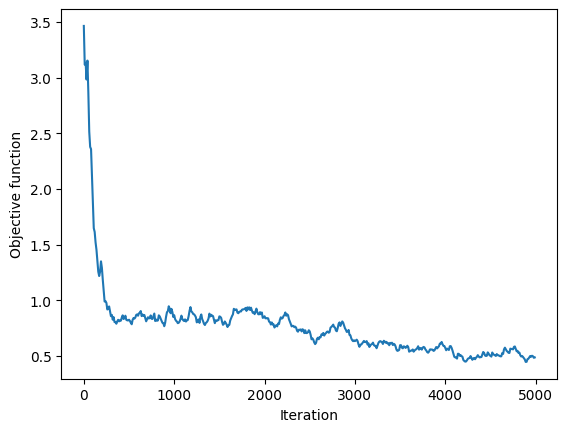

In [66]:
lamb = 0
n_iter = 5000
n_batch = 1
gamma = lambda t: 1 / (np.sqrt(t)+100)

mlr = MyFederatedPrivateSGDLogisticRegression(gamma, n_iter, lamb, n_batch=n_batch, epsilon=1, delta=1e-5, c=1, random_state=42)
mlr.fit(features, labels)
print("Test accuracy", mlr.score(X_test, y_test))

obj_list = mlr.obj_list_
iter_list = np.arange(len(obj_list)) * mlr.freq_obj_eval
plt.plot(iter_list, obj_list)
plt.xlabel("Iteration")
plt.ylabel("Objective function")
plt.show()